# Healthcare Readmission Analysis

Phase-1 Business Problem

Hospital readmissions increase healthcare costs and indicate potential gaps in patient care. Identifying the factors associated with diabetic patient readmissions can help hospitals improve treatment quality and reduce unnecessary readmissions.

## Project Objective

Analyze diabetic patient records to identify the major factors influencing hospital readmissions and provide actionable business recommendations.

## Stakeholders

- Hospital Management
- Physicians
- Care Coordinators
- Healthcare Administrators

## KPIs

- Total Patients
- Readmission Rate
- Average Length of Stay
- Average Medications
- Average Lab Procedures
- Average Diagnoses

Phase-2 Data Understanding

## Initial Dataset Observations

Dataset Name:
Diabetes 130-US Hospitals for Years 1999–2008

Source:
Kaggle

Initial Shape:
101,766 Rows
50 Columns

 ## Key Findings

- Dataset contains patient demographics.
- Dataset contains medication information.
- Dataset contains diagnosis codes.
- Target variable is "readmitted".
- Missing values are represented by '?' and NaN.

In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("diabetic_data.csv")
mapping = pd.read_csv("IDS_mapping.csv")


In [4]:
df.shape

(101766, 50)

In [5]:
# Display dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
# Generate summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [8]:
df.describe(include='object').T

,count,unique,top,freq
race,101766,6,Caucasian,76099
gender,101766,3,Female,54708
age,101766,10,[70-80),26068
weight,101766,10,?,98569
payer_code,101766,18,?,40256
medical_specialty,101766,73,?,49949
diag_1,101766,717,428,6862
diag_2,101766,749,276,6752
diag_3,101766,790,250,11555
max_glu_serum,5346,3,Norm,2597


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [11]:
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [12]:
(df == '?').sum().sort_values(ascending=False)

weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
tolazamide                      0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
citoglipton                     0
examide                         0
acetohexamide                   0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glipizide                       0
repaglinide                     0
glimepiride   

In [13]:

df[['weight', 'medical_specialty', 'payer_code']].head(10)



,weight,medical_specialty,payer_code
0,?,Pediatrics-Endocrinology,?
1,?,?,?
2,?,?,?
3,?,?,?
4,?,?,?
5,?,?,?
6,?,?,?
7,?,?,?
8,?,?,?
9,?,InternalMedicine,?


In [14]:

for col in ['weight', 'medical_specialty', 'payer_code']:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(15))


weight
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

medical_specialty
medical_specialty
?                                  49949
InternalMedicine                   14635
Emergency/Trauma                    7565
Family/GeneralPractice              7440
Cardiology                          5352
Surgery-General                     3099
Nephrology                          1613
Orthopedics                         1400
Orthopedics-Reconstructive          1233
Radiologist                         1140
Pulmonology                          871
Psychiatry                           854
Urology                              685
ObstetricsandGynecology              671
Surgery-Cardiovascular/Thoracic      652
Name: count, dtype: int64

payer_code
payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3

In [15]:
df.duplicated().sum()



np.int64(0)

In [16]:
df['patient_nbr'].nunique()

71518

In [17]:
df['readmitted'].value_counts()


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [18]:
df['readmitted'].value_counts(normalize=True) * 100


readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

Phase-3 Data Cleaning

Objective:
Prepare the dataset for analysis by handling missing values, removing unnecessary columns, and improving overall data quality.

In [19]:
df_clean = df.copy()

In [20]:
df_clean.shape

(101766, 50)

In [21]:
# Replace '?' with NaN so that pandas can identify missing values correctly
import numpy as np

df_clean.replace('?', np.nan, inplace=True)

In [22]:
df_clean.isnull().sum().sort_values(ascending=False).head(10)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
dtype: int64

In [23]:
print(df_clean['max_glu_serum'].value_counts(dropna=False))

print("-" * 50)

print(df_clean['A1Cresult'].value_counts(dropna=False))

max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64
--------------------------------------------------
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64


In [24]:
# Drop columns with extremely high missing values or low analytical value
columns_to_drop = [
    'weight',
    'payer_code',
    'max_glu_serum',
    'A1Cresult'
]

df_clean.drop(columns=columns_to_drop, inplace=True)

In [25]:

df_clean.shape

(101766, 46)

In [26]:
df_clean.isnull().sum().sort_values(ascending=False)

medical_specialty           49949
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
tolazamide                      0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
citoglipton                     0
examide                         0
glipizide                       0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glyburide                       0
chlorpropamide                  0
acetohexamide                   0
glimepiride                     0
gender                          0
age           

In [27]:
df_clean[df_clean[['diag_1', 'diag_2', 'diag_3']].isnull().any(axis=1)].shape

(1522, 46)

In [28]:
# Fill missing categorical values
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Unknown')
df_clean['race'] = df_clean['race'].fillna('Unknown')

In [29]:
# Remove records with missing diagnosis information
df_clean.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)


In [30]:
df_clean.isnull().sum().sort_values(ascending=False).head(10)

encounter_id     0
tolazamide       0
acetohexamide    0
glipizide        0
glyburide        0
tolbutamide      0
pioglitazone     0
rosiglitazone    0
acarbose         0
miglitol         0
dtype: int64

In [31]:
df_clean.shape

(100244, 46)

In [32]:
df_clean['gender'].value_counts(dropna=False)

df_clean['readmitted'].value_counts()

df_clean['diabetesMed'].value_counts()

df_clean['change'].value_counts()

change
No    53892
Ch    46352
Name: count, dtype: int64

In [33]:
df_clean['gender'].value_counts(dropna=False)

gender
Female             53922
Male               46319
Unknown/Invalid        3
Name: count, dtype: int64

In [34]:
# Remove records with invalid gender
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']

In [35]:
df_clean['gender'].value_counts()

gender
Female    53922
Male      46319
Name: count, dtype: int64

In [36]:
df_clean['readmitted'].value_counts()

readmitted
NO     53818
>30    35173
<30    11250
Name: count, dtype: int64

In [37]:
df_clean['diabetesMed'].value_counts()

diabetesMed
Yes    77153
No     23088
Name: count, dtype: int64

In [38]:
mapping.head(20)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


In [39]:
mapping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   admission_type_id  65 non-null     object
 1   description        62 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [40]:
mapping.tail(30)

,admission_type_id,description
37,27,Discharged/transferred to a federal health car...
38,28,Discharged/transferred/referred to a psychiatr...
39,29,Discharged/transferred to a Critical Access Ho...
40,NaN,NaN
41,admission_source_id,description
42,1,Physician Referral
43,2,Clinic Referral
44,3,HMO Referral
45,4,Transfer from a hospital
46,5,Transfer from a Skilled Nursing Facility (SNF)


In [41]:
for col in df_clean.columns:
    if df_clean[col].nunique() == 1:
        print(col, ":", df_clean[col].unique())

examide : ['No']
citoglipton : ['No']


In [42]:

# Drop constant-value columns
df_clean.drop(columns=['examide', 'citoglipton'], inplace=True)

In [43]:
df_clean.shape

(100241, 44)

In [44]:
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

df_clean[numerical_cols].describe()



,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.002410e+05,1.002410e+05,100241.000000,100241.000000,100241.000000,100241.000000,100241.000000,100241.000000,100241.000000,100241.000000,100241.000000,100241.000000,100241.000000
mean,1.660164e+08,5.462896e+07,2.022765,3.729153,5.760627,4.420307,43.173991,1.350236,16.117816,0.372572,0.199020,0.639489,7.497052
std,1.026763e+08,3.869475e+07,1.444926,5.280776,4.063118,2.991258,19.691339,1.710899,8.116446,1.274092,0.933554,1.262787,1.839509
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000
25%,8.556620e+07,2.346089e+07,1.000000,1.000000,1.000000,2.000000,32.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000
50%,1.530489e+08,4.604908e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.310624e+08,8.778530e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [45]:
df_clean.to_csv("healthcare_cleaned_data.csv", index=False)

## Data Cleaning Summary

- Converted '?' values to NaN.
- Removed columns with excessive missing values:
  - weight
  - payer_code
  - max_glu_serum
  - A1Cresult
- Filled missing values in medical_specialty and race with "Unknown".
- Removed records with missing diagnosis information.
- Removed invalid gender records.
- Removed constant columns:
  - examide
  - citoglipton

Final Dataset:
- Rows: 100,241
- Columns: 44
- Missing Values: 0

## Final Dataset

Rows : 100241

Columns : 44

Missing Values : 0

Duplicate Rows : 0

Phase-4 Feature Engineering

This section will focus on creating meaningful business features to improve healthcare analysis and dashboard insights.

# Feature 1: Total Hospital Visits

### Business Purpose

This feature represents the total number of previous hospital interactions by combining outpatient visits, emergency visits, and inpatient admissions.

It helps identify patients with high healthcare utilization, who may be at greater risk of future readmissions.

In [46]:
# Create total hospital visits feature
df_clean['total_visits'] = (
    df_clean['number_outpatient'] +
    df_clean['number_emergency'] +
    df_clean['number_inpatient']
)

# Verify the new feature
df_clean[['number_outpatient',
          'number_emergency',
          'number_inpatient',
          'total_visits']].head()

,number_outpatient,number_emergency,number_inpatient,total_visits
1,0,0,0,0
2,2,0,1,3
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0


In [47]:
df_clean['total_visits']

1         0
2         3
3         0
4         0
5         0
         ..
101761    0
101762    1
101763    1
101764    1
101765    0
Name: total_visits, Length: 100241, dtype: int64

In [48]:
df_clean['total_visits'].describe()

count    100241.000000
mean          1.211081
std           2.298249
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          80.000000
Name: total_visits, dtype: float64

In [49]:
df_clean['total_visits'].value_counts().sort_index()

total_visits
0     54702
1     19742
2      9986
3      5860
4      3544
5      2018
6      1300
7       863
8       546
9       429
10      270
11      246
12      136
13       98
14       86
15       95
16       67
17       62
18       32
19       30
20       23
21       14
22       15
23        4
24        9
25        7
26        6
27        9
28        2
29        5
30        4
31        2
32        2
33        2
34        1
35        5
36        5
37        2
38        2
40        1
41        1
42        2
48        1
49        1
61        1
68        2
80        1
Name: count, dtype: int64

## Feature 2: Visit Category

### Business Purpose

Patients were grouped based on their previous healthcare utilization. This feature helps identify whether patients with frequent hospital visits are more likely to experience readmission.

In [50]:
# Create visit category
def visit_category(visits):
    if visits == 0:
        return 'No Previous Visits'
    elif visits <= 2:
        return 'Low Utilization'
    elif visits <= 5:
        return 'Moderate Utilization'
    else:
        return 'High Utilization'

df_clean['visit_category'] = df_clean['total_visits'].apply(visit_category)

# Check the distribution
df_clean['visit_category'].value_counts()

visit_category
No Previous Visits      54702
Low Utilization         29728
Moderate Utilization    11422
High Utilization         4389
Name: count, dtype: int64

In [51]:
df_clean.to_csv("healthcare_feature_engineered_v1.csv", index=False)

## Feature 3: Stay Category

### Business Purpose

Patients were categorized based on the length of their hospital stay. This helps analyze whether longer hospitalizations are associated with higher readmission rates.

In [52]:
# Create hospital stay categories
def stay_category(days):
    if days <= 3:
        return 'Short Stay'
    elif days <= 7:
        return 'Medium Stay'
    else:
        return 'Long Stay'

df_clean['stay_category'] = df_clean['time_in_hospital'].apply(stay_category)

# Verify the feature
df_clean['stay_category'].value_counts()

stay_category
Short Stay     48043
Medium Stay    36964
Long Stay      15234
Name: count, dtype: int64

## Feature 4: Medication Load

### Business Purpose

Patients were categorized based on the total number of medications prescribed during hospitalization. This feature helps identify whether patients with a higher medication burden are more likely to experience hospital readmission.

In [53]:
# Create medication load category
def medication_load(medications):
    if medications <= 10:
        return 'Low Medication'
    elif medications <= 20:
        return 'Medium Medication'
    else:
        return 'High Medication'

df_clean['medication_load'] = df_clean['num_medications'].apply(medication_load)

# Verify the feature
df_clean['medication_load'].value_counts()

medication_load
Medium Medication    51583
Low Medication       24875
High Medication      23783
Name: count, dtype: int64

In [54]:
df_clean.to_csv("healthcare_feature_engineered_v2.csv", index=False)

## Feature 5: Diagnosis Complexity

### Business Purpose

Patients were categorized based on the number of diagnoses recorded during hospitalization. This feature helps evaluate whether patients with more complex medical conditions have a higher likelihood of hospital readmission.

In [55]:
# Create diagnosis complexity category
def diagnosis_complexity(diagnoses):
    if diagnoses <= 5:
        return 'Low Complexity'
    elif diagnoses <= 8:
        return 'Medium Complexity'
    else:
        return 'High Complexity'

df_clean['diagnosis_complexity'] = df_clean['number_diagnoses'].apply(diagnosis_complexity)

# Verify the feature
df_clean['diagnosis_complexity'].value_counts()

diagnosis_complexity
High Complexity      49581
Medium Complexity    31080
Low Complexity       19580
Name: count, dtype: int64

## Feature 6: Age Midpoint

### Business Purpose

The original age variable is stored as age ranges. Converting these ranges into approximate midpoint values allows numerical analysis, easier visualization, and better comparison across patient age groups.

In [56]:
# Age range to midpoint mapping
age_mapping = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}

df_clean['age_midpoint'] = df_clean['age'].map(age_mapping)

# Verify the feature
df_clean[['age', 'age_midpoint']].head(10)

,age,age_midpoint
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45
5,[50-60),55
6,[60-70),65
7,[70-80),75
8,[80-90),85
9,[90-100),95
10,[40-50),45


In [57]:
df_clean.to_csv("healthcare_feature_engineered_v2.csv", index=False)

## Feature 7: Readmission Binary

### Business Purpose

The original `readmitted` column contains three categories (`NO`, `>30`, and `<30`). For certain analyses, KPIs, and future predictive modeling, it is useful to create a binary feature where any readmission is treated as "Yes".

This simplifies comparisons while preserving the original `readmitted` column for detailed analysis.

In [58]:
# Create binary readmission feature
df_clean['readmission_binary'] = df_clean['readmitted'].map({
    'NO': 0,
    '>30': 1,
    '<30': 1
})

# Verify the feature
df_clean['readmission_binary'].value_counts()

readmission_binary
0    53818
1    46423
Name: count, dtype: int64

In [59]:
df_clean.to_csv("healthcare_feature_engineered_final.csv", index=False)

# Feature Engineering Summary

The following business-oriented features were created to enhance the analytical value of the dataset:

- Total Hospital Visits
- Visit Category
- Stay Category
- Medication Load
- Diagnosis Complexity
- Age Midpoint
- Readmission Binary

These engineered features improve business analysis, simplify visualization, and support better healthcare decision-making.

# Phase 5: Exploratory Data Analysis (EDA)

## Objective

The objective of this phase is to explore the dataset, identify key patterns, answer important business questions, and generate actionable insights that can help healthcare organizations reduce hospital readmissions.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned dataset
df_clean = pd.read_csv("healthcare_feature_engineered_final.csv")

# Check dataset
df_clean.shape

(100241, 51)

## Business Question 1

### What is the overall hospital readmission rate?

This analysis measures the proportion of patients who were readmitted after discharge and provides an overview of hospital readmission patterns.

In [61]:
# Readmission distribution
readmission_counts = df_clean['readmitted'].value_counts()

# Readmission percentage
readmission_percentage = round(
    df_clean['readmitted'].value_counts(normalize=True) * 100,
    2
)

print(readmission_counts)

print("\nPercentage")
print(readmission_percentage)

readmitted
NO     53818
>30    35173
<30    11250
Name: count, dtype: int64

Percentage
readmitted
NO     53.69
>30    35.09
<30    11.22
Name: proportion, dtype: float64


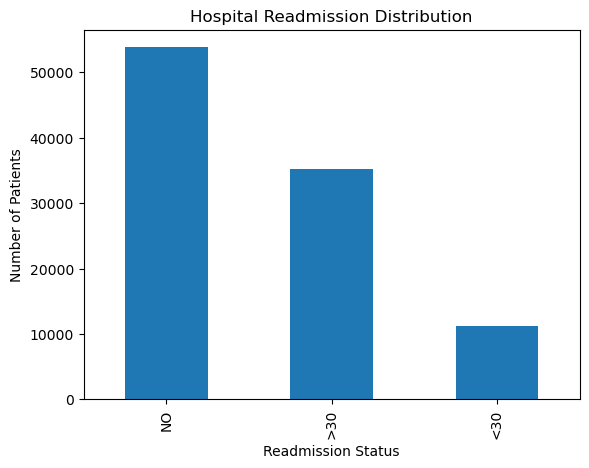

In [62]:
import matplotlib.pyplot as plt

readmission_counts.plot(kind='bar')

plt.title("Hospital Readmission Distribution")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")

plt.show()

### Business Insight

- More than half of the patients (53.69%) were not readmitted after discharge.
- However, 46.31% of patients experienced at least one hospital readmission.
- Among all patients, 11.22% were readmitted within 30 days, which is often considered a key quality indicator in healthcare

### Recommendation

Hospitals should identify patient groups with higher readmission rates and implement targeted follow-up programs, medication counseling, and post-discharge monitoring to reduce avoidable readmissions.

### Business Impact

- Helps hospital management understand the overall readmission burden.
- Supports monitoring of healthcare quality and patient outcomes.
- Provides a baseline KPI for evaluating future readmission reduction initiatives.
- Assists decision-makers in identifying the need for targeted patient follow-up programs.

## Business Question 2

### What is the gender distribution of diabetic patients?

This analysis examines the proportion of male and female patients in the dataset to understand the demographic distribution of hospital admissions.

In [63]:
# Gender distribution
gender_counts = df_clean['gender'].value_counts()

gender_percentage = round(
    df_clean['gender'].value_counts(normalize=True) * 100,
    2
)

print(gender_counts)

print("\nPercentage")
print(gender_percentage)

gender
Female    53922
Male      46319
Name: count, dtype: int64

Percentage
gender
Female    53.79
Male      46.21
Name: proportion, dtype: float64


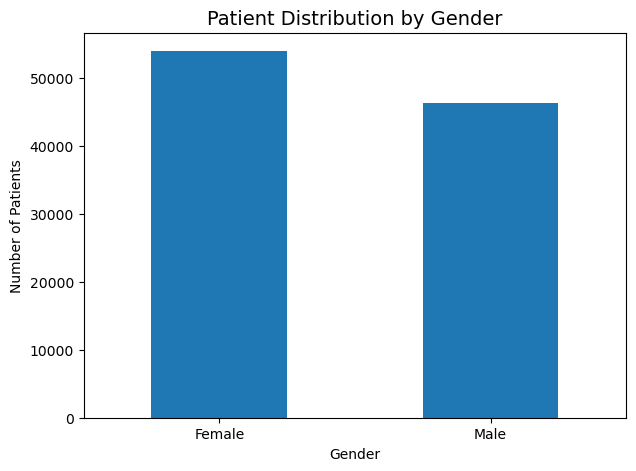

In [64]:
plt.figure(figsize=(7,5))

gender_counts.plot(kind='bar')

plt.title("Patient Distribution by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.show()

### Business Insight

- Female patients accounted for 53.79% of all hospital admissions, while male patients represented 46.21%.
- The patient population is relatively balanced between genders, with a slightly higher proportion of female patients.
- Since the difference is modest, gender alone may not be a strong indicator of hospital readmission. Further analysis is required to compare readmission rates between male and female patients.

### Recommendation

Hospitals should monitor readmission trends separately for male and female patients to identify whether gender-specific healthcare interventions or follow-up programs are required. Resource planning should consider the slightly higher proportion of female patients while ensuring equitable care for both groups.

### Business Impact

- Helps hospitals evaluate whether healthcare services are being delivered equitably across genders.
- Supports demographic analysis for patient population planning.
- Enables healthcare providers to focus interventions on clinical risk factors rather than demographic assumptions.
- Provides evidence for fair and unbiased healthcare decision-making.

## Business Question 3

### What is the age distribution of diabetic patients?

This analysis examines the distribution of patients across different age groups to identify which age categories account for the highest number of hospital admissions.

In [65]:
# Age distribution
age_counts = df_clean['age'].value_counts().sort_index()

age_percentage = round(
    df_clean['age'].value_counts(normalize=True).sort_index() * 100,
    2
)

print(age_counts)

print("\nPercentage")
print(age_percentage)

age
[0-10)         65
[10-20)       469
[20-30)      1515
[30-40)      3616
[40-50)      9474
[50-60)     17044
[60-70)     22287
[70-80)     25896
[80-90)     17090
[90-100)     2785
Name: count, dtype: int64

Percentage
age
[0-10)       0.06
[10-20)      0.47
[20-30)      1.51
[30-40)      3.61
[40-50)      9.45
[50-60)     17.00
[60-70)     22.23
[70-80)     25.83
[80-90)     17.05
[90-100)     2.78
Name: proportion, dtype: float64


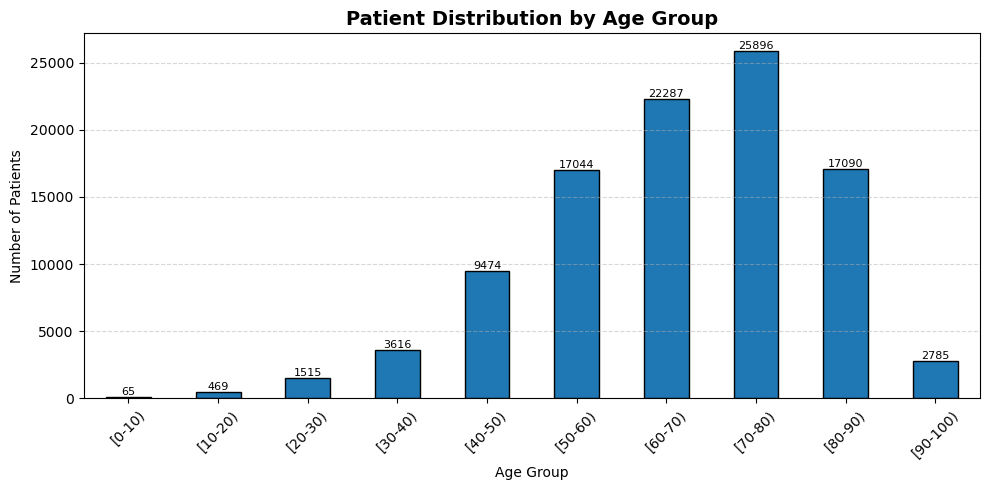

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

ax = age_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Patient Distribution by Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8)

plt.tight_layout()
plt.show()

### Key Findings

- The largest patient group falls within the **70–80 years** age range, accounting for **25.83%** of all diabetic hospital admissions.
- Patients aged **60–80 years** together represent nearly half of the total patient population, indicating that older adults account for the majority of hospitalizations.
- Very young patients (below 30 years) contribute only a small proportion of admissions.
- The distribution suggests that diabetes-related hospitalizations increase significantly with age before gradually declining in the oldest age groups.

### Business Insight

Older adults, particularly those between **60 and 80 years**, represent the largest proportion of diabetic hospital admissions. This indicates that healthcare providers should prioritize preventive care, chronic disease management, and regular monitoring for elderly diabetic patients, as they are the primary users of inpatient services.

### Recommendation

Hospitals should strengthen diabetes management programs for patients aged **60 years and above** by providing routine health monitoring, medication adherence support, and lifestyle counseling. Targeted interventions for these age groups may improve patient outcomes and reduce future hospitalizations.

### Business Impact

- Helps hospitals identify the age groups that require the greatest healthcare resources.
- Supports capacity planning for elderly diabetic patients.
- Assists in designing age-specific diabetes management and preventive care programs.
- Improves long-term healthcare planning by understanding demographic trends.

## Business Question 4

### Which age groups have the highest hospital readmission rate?

This analysis evaluates readmission patterns across different age groups to determine whether patient age influences the likelihood of hospital readmission.

In [67]:
# Readmission by age group
age_readmission = pd.crosstab(
    df_clean['age'],
    df_clean['readmitted'],
    normalize='index'
) * 100

age_readmission = age_readmission.round(2)

print(age_readmission)

readmitted    <30    >30     NO
age                            
[0-10)       1.54  20.00  78.46
[10-20)      6.61  35.18  58.21
[20-30)     14.32  30.83  54.85
[30-40)     11.34  31.91  56.75
[40-50)     10.75  34.06  55.19
[50-60)      9.74  34.49  55.77
[60-70)     11.18  35.20  53.62
[70-80)     11.80  36.41  51.79
[80-90)     12.05  36.21  51.74
[90-100)    11.02  28.98  60.00


<Figure size 1100x600 with 0 Axes>

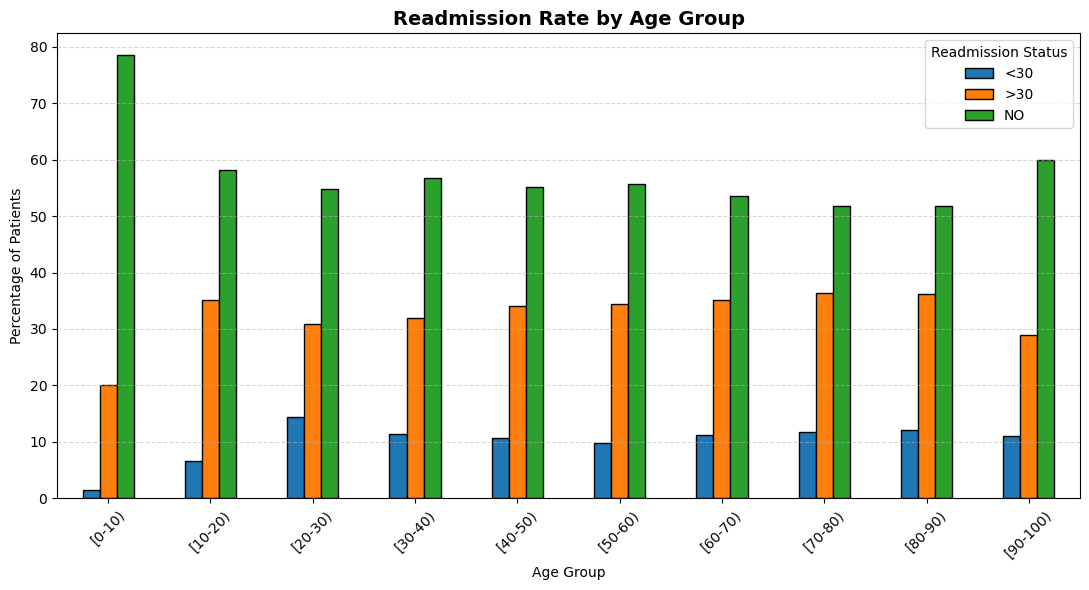

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11,6))

age_readmission.plot(
    kind='bar',
    figsize=(11,6),
    edgecolor='black'
)

plt.title("Readmission Rate by Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Percentage of Patients")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Readmission Status")

plt.tight_layout()

plt.show()

In [69]:
print(age_readmission)

readmitted    <30    >30     NO
age                            
[0-10)       1.54  20.00  78.46
[10-20)      6.61  35.18  58.21
[20-30)     14.32  30.83  54.85
[30-40)     11.34  31.91  56.75
[40-50)     10.75  34.06  55.19
[50-60)      9.74  34.49  55.77
[60-70)     11.18  35.20  53.62
[70-80)     11.80  36.41  51.79
[80-90)     12.05  36.21  51.74
[90-100)    11.02  28.98  60.00


### Key Findings

- Patients aged **70–80 years** had the highest proportion of readmissions occurring after 30 days (36.41%).
- Patients aged **20–30 years** showed the highest percentage of readmissions within 30 days (14.32%), although this age group represents a much smaller patient population.
- Patients aged **0–10 years** had the highest percentage of patients with no readmission (78.46%).
- Overall, patients aged **60–90 years** consistently showed lower "No Readmission" percentages, indicating a greater likelihood of returning to the hospital.

### Business Insight

Age appears to be an important factor associated with hospital readmission. Older patients, particularly those between **60 and 90 years**, experience higher readmission rates compared with younger patients. This may be related to chronic disease burden, multiple health conditions, and the need for ongoing medical care after discharge.

### Recommendation

Hospitals should prioritize post-discharge care for patients aged **60 years and above** by implementing follow-up appointments, medication reviews, and chronic disease management programs. Early intervention for these high-risk age groups may help reduce avoidable readmissions and improve patient outcomes.

### Business Impact

- Helps hospitals identify age groups at higher risk of hospital readmission.
- Supports targeted discharge planning and follow-up care for elderly patients.
- Enables healthcare providers to allocate resources toward high-risk patient populations.
- Contributes to reducing avoidable readmissions through age-focused intervention strategies.

## Business Question 5

### Does gender influence hospital readmission?

This analysis compares hospital readmission patterns between male and female patients to determine whether gender is associated with differences in readmission outcomes.

In [70]:
# Readmission by gender
gender_readmission = pd.crosstab(
    df_clean['gender'],
    df_clean['readmitted'],
    normalize='index'
) * 100

gender_readmission = gender_readmission.round(2)

print(gender_readmission)

readmitted    <30    >30     NO
gender                         
Female      11.30  35.82  52.89
Male        11.14  34.24  54.62


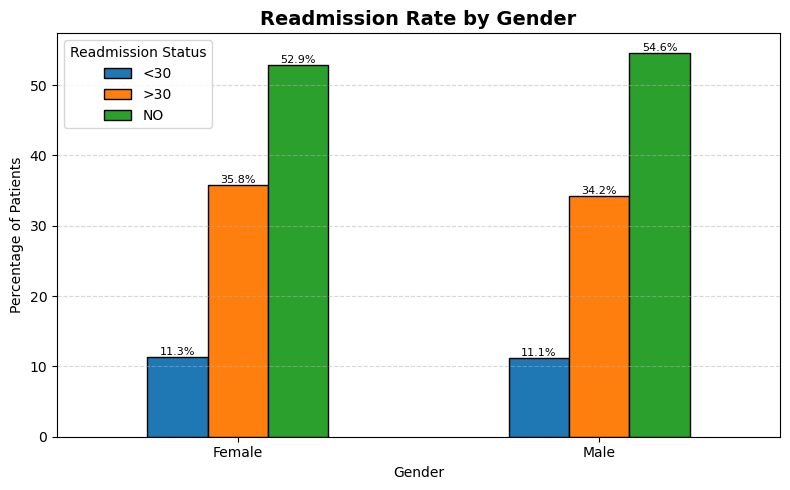

In [71]:
import matplotlib.pyplot as plt

ax = gender_readmission.plot(
    kind='bar',
    figsize=(8,5),
    edgecolor='black'
)

plt.title("Readmission Rate by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Percentage of Patients")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Readmission Status")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()

plt.show()

### Key Findings

- Female and male patients showed very similar hospital readmission patterns.
- Female patients had a slightly higher proportion of readmissions after 30 days (35.82%) compared to male patients (34.24%).
- Readmissions within 30 days were nearly identical for both genders (11.30% for females and 11.14% for males).
- The difference in readmission percentages between genders is relatively small.

### Business Insight

Gender does not appear to be a major differentiating factor in hospital readmission patterns within this dataset. Both male and female patients exhibit comparable readmission rates, suggesting that other factors such as age, disease complexity, medication burden, or healthcare utilization may have a stronger association with readmission outcomes.

### Recommendation

Rather than designing gender-specific interventions, hospitals should focus on clinical and operational factors such as patient age, diagnosis complexity, medication management, and previous healthcare utilization when developing readmission reduction strategies.

### Business Impact

- Enables hospitals to prioritize interventions based on clinical risk rather than gender.
- Supports more efficient allocation of healthcare resources.
- Encourages evidence-based decision-making for readmission reduction programs.
- Helps improve patient care by focusing on factors with greater potential impact.

## Business Question 6

### Which admission type has the highest hospital readmission rate?

This analysis evaluates whether patients admitted through different admission types experience different hospital readmission patterns.

In [72]:
# Admission type mapping
admission_mapping = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    4: 'Newborn',
    5: 'Not Available',
    6: 'Unknown',
    7: 'Trauma Center',
    8: 'Not Mapped'
}

df_clean['admission_type'] = df_clean['admission_type_id'].map(admission_mapping)

# Check mapping
df_clean[['admission_type_id', 'admission_type']].head()

,admission_type_id,admission_type
0,1,Emergency
1,1,Emergency
2,1,Emergency
3,1,Emergency
4,2,Urgent


In [73]:
# Readmission by admission type
admission_readmission = pd.crosstab(
    df_clean['admission_type'],
    df_clean['readmitted'],
    normalize='index'
) * 100

admission_readmission = admission_readmission.round(2)

print(admission_readmission)

readmitted        <30    >30      NO
admission_type                      
Elective        10.44  30.55   59.01
Emergency       11.57  35.92   52.51
Newborn         10.00  20.00   70.00
Not Available   10.45  36.02   53.53
Not Mapped       8.57  26.35   65.08
Trauma Center    0.00   0.00  100.00
Unknown         11.19  42.35   46.45
Urgent          11.28  35.15   53.57


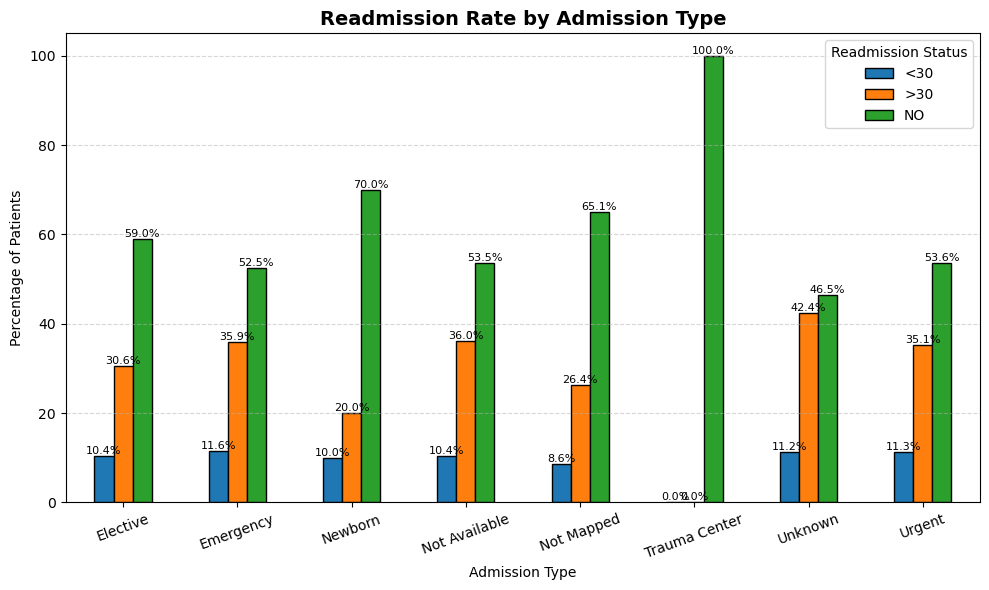

In [74]:
import matplotlib.pyplot as plt

ax = admission_readmission.plot(
    kind='bar',
    figsize=(10,6),
    edgecolor='black'
)

plt.title("Readmission Rate by Admission Type",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Admission Type")
plt.ylabel("Percentage of Patients")

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Readmission Status")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()
plt.show()

In [75]:
print(admission_readmission)

readmitted        <30    >30      NO
admission_type                      
Elective        10.44  30.55   59.01
Emergency       11.57  35.92   52.51
Newborn         10.00  20.00   70.00
Not Available   10.45  36.02   53.53
Not Mapped       8.57  26.35   65.08
Trauma Center    0.00   0.00  100.00
Unknown         11.19  42.35   46.45
Urgent          11.28  35.15   53.57


In [76]:
df_clean['admission_type'].value_counts()

admission_type
Emergency        53230
Elective         18544
Urgent           18203
Unknown           5199
Not Available     4719
Not Mapped         315
Trauma Center       21
Newborn             10
Name: count, dtype: int64

### Key Findings

- Emergency admissions showed a higher proportion of readmissions compared to elective admissions.
- Elective admissions had the highest percentage of patients with no readmission (59.01%) among the major admission types.
- Urgent and Emergency admissions displayed similar readmission patterns, with approximately one-third of patients being readmitted after 30 days.
- Trauma Center and Newborn admission types contain very small sample sizes (21 and 10 patients, respectively). Their readmission percentages should be interpreted cautiously and should not be generalized to the broader patient population.

### Business Insight

Admission type appears to be associated with hospital readmission patterns. Patients admitted through emergency services tend to experience higher readmission rates than those admitted electively. This suggests that emergency admissions may involve patients with more severe or complex medical conditions requiring additional follow-up care.

### Recommendation

Hospitals should prioritize discharge planning and post-discharge follow-up for patients admitted through emergency services. Enhanced care coordination, medication counseling, and early follow-up appointments may help reduce avoidable readmissions among these higher-risk patients.

### Business Impact

- Supports identification of high-risk admission pathways.
- Helps hospitals prioritize discharge planning for emergency patients.
- Improves allocation of follow-up care resources.
- Contributes to reducing avoidable hospital readmissions.

## Business Question 7

### Does hospital stay duration affect hospital readmission?

This analysis investigates whether patients with longer hospital stays are more likely to experience hospital readmission after discharge.

In [77]:
# Readmission by stay category
stay_readmission = pd.crosstab(
    df_clean['stay_category'],
    df_clean['readmitted'],
    normalize='index'
) * 100

stay_readmission = stay_readmission.round(2)

print(stay_readmission)

readmitted       <30    >30     NO
stay_category                     
Long Stay      13.40  36.26  50.34
Medium Stay    12.20  36.38  51.42
Short Stay      9.78  33.72  56.50


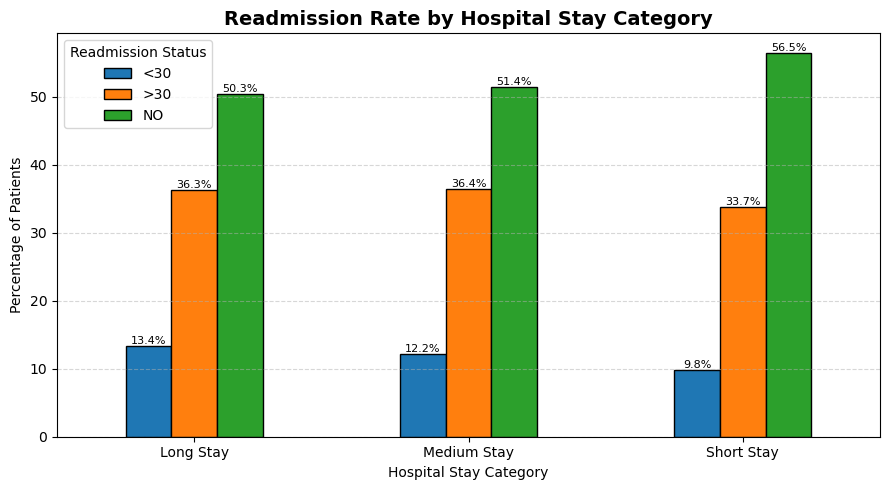

In [78]:
import matplotlib.pyplot as plt

ax = stay_readmission.plot(
    kind='bar',
    figsize=(9,5),
    edgecolor='black'
)

plt.title("Readmission Rate by Hospital Stay Category",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Hospital Stay Category")
plt.ylabel("Percentage of Patients")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Readmission Status")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()
plt.show()

In [79]:
print(stay_readmission)


readmitted       <30    >30     NO
stay_category                     
Long Stay      13.40  36.26  50.34
Medium Stay    12.20  36.38  51.42
Short Stay      9.78  33.72  56.50


### Key Findings

- Patients with **long hospital stays** had the highest proportion of readmissions within 30 days (13.40%).
- Patients with **short hospital stays** had the highest percentage of no readmission (56.50%).
- Readmission rates generally increased as the length of hospital stay increased.
- Medium and long hospital stays showed similar patterns, suggesting that patients requiring extended hospitalization may have more complex healthcare needs.

### Business Insight

Hospital stay duration appears to be associated with patient readmission. Patients who remained in the hospital for longer periods were more likely to experience readmission, which may reflect greater disease severity, multiple health conditions, or increased treatment complexity.

### Recommendation

Hospitals should implement enhanced discharge planning and follow-up programs for patients with medium and long hospital stays. Medication reconciliation, discharge education, and scheduled follow-up appointments may help reduce avoidable readmissions among these higher-risk patients.

### Business Impact

- Improves identification of patients requiring additional post-discharge support.
- Helps hospitals prioritize discharge planning resources.
- Supports initiatives to reduce avoidable readmissions and improve patient outcomes.
- Enhances resource utilization by focusing on higher-risk patient groups.

## Business Question 8

### Do patients taking more medications have higher hospital readmission rates?

This analysis examines whether medication burden is associated with hospital readmission among diabetic patients. Patients were grouped into medication load categories during the feature engineering phase.

In [80]:
# Readmission by medication load
medication_readmission = pd.crosstab(
    df_clean['medication_load'],
    df_clean['readmitted'],
    normalize='index'
) * 100

medication_readmission = medication_readmission.round(2)

print(medication_readmission)

readmitted           <30    >30     NO
medication_load                       
High Medication    12.79  36.03  51.18
Low Medication      9.18  30.78  60.04
Medium Medication  11.49  36.73  51.78


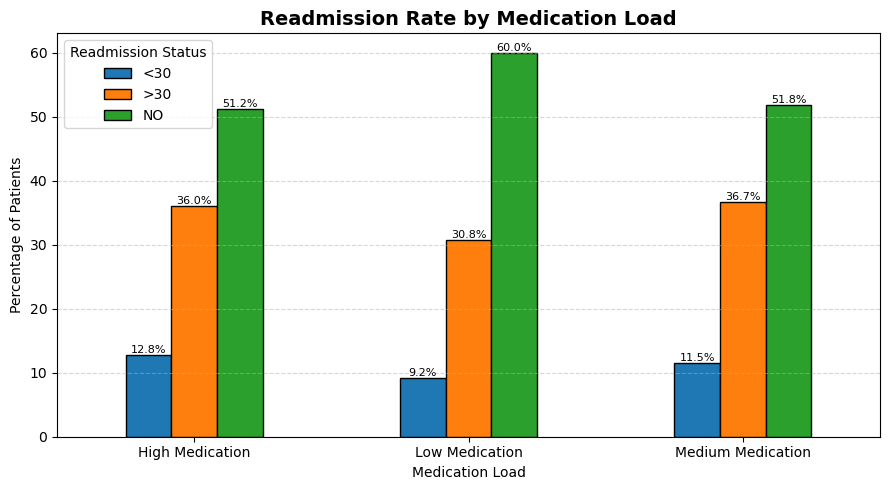

In [81]:
import matplotlib.pyplot as plt

ax = medication_readmission.plot(
    kind='bar',
    figsize=(9,5),
    edgecolor='black'
)

plt.title("Readmission Rate by Medication Load",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Medication Load")
plt.ylabel("Percentage of Patients")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Readmission Status")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()

plt.show()

### Key Findings

- Patients with **low medication load** had the highest percentage of no readmission (60.04%).
- Patients with **high medication load** showed the highest proportion of readmissions within 30 days (12.79%).
- Both medium and high medication groups experienced considerably higher readmission rates than the low medication group.
- As medication burden increased, the percentage of patients with no readmission decreased.

### Business Insight

Medication burden appears to be associated with hospital readmission. Patients prescribed a greater number of medications experienced higher readmission rates, which may indicate more complex medical conditions, multiple chronic illnesses, or increased treatment complexity.

### Recommendation

Hospitals should prioritize medication management for patients with medium and high medication loads. Regular medication reviews, pharmacist consultations, discharge counseling, and follow-up monitoring may help improve medication adherence and reduce avoidable readmissions.

### Business Impact

- Improves medication safety and adherence.
- Helps identify high-risk patients before discharge.
- Supports targeted pharmacist-led interventions.
- Contributes to reducing avoidable hospital readmissions and improving patient outcomes.

## Business Question 9: Does the Number of Diagnoses Influence Hospital Readmission?

### Objective
Analyze whether patients with a higher number of diagnosed medical conditions are more likely to be readmitted within 30 days, after 30 days, or not readmitted at all.

### Why This Matters
Patients with multiple diagnoses often have more complex medical needs. Understanding this relationship can help healthcare providers identify high-risk patients and implement targeted interventions to reduce avoidable readmissions.

In [82]:
df['diagnosis_load'] = pd.cut(
    df['number_diagnoses'],
    bins=[0, 4, 8, 16],
    labels=['Low Diagnosis', 'Medium Diagnosis', 'High Diagnosis'],
    include_lowest=True
)

In [83]:
diagnosis_readmission = (
    pd.crosstab(df['diagnosis_load'], df['readmitted'], normalize='index') * 100
).round(2)

diagnosis_readmission

readmitted,<30,>30,NO
diagnosis_load,,,
Low Diagnosis,7.71,27.90,64.40
Medium Diagnosis,10.51,32.71,56.78
High Diagnosis,12.39,38.19,49.42


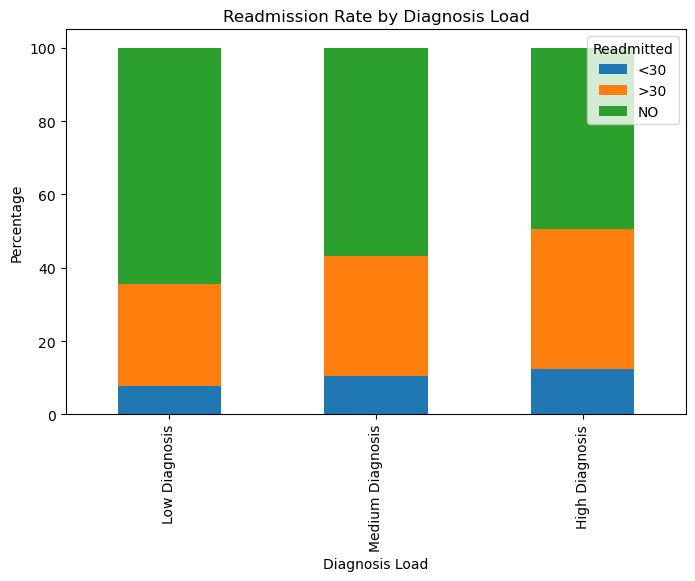

In [84]:
diagnosis_readmission.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Readmission Rate by Diagnosis Load')
plt.xlabel('Diagnosis Load')
plt.ylabel('Percentage')
plt.legend(title='Readmitted')
plt.show()

 Key Findings
Patients with High Diagnosis Load have the highest overall readmission rate, with 12.39% readmitted within 30 days and 38.19% after 30 days.
Patients with Low Diagnosis Load have the lowest readmission risk, with only 7.71% readmitted within 30 days and 27.90% after 30 days.
The percentage of patients with no readmission decreases as the number of diagnoses increases:
Low Diagnosis: 64.40%
Medium Diagnosis: 56.78%
High Diagnosis: 49.42%
This indicates a clear trend that patients with multiple diagnosed conditions are more likely to experience hospital readmission.

 Business Insight

Patients with a higher number of diagnosed medical conditions require more complex clinical management, making them more vulnerable to complications and repeat hospital visits. The steady increase in readmission rates with diagnosis load suggests that disease complexity is an important predictor of readmission risk.

Recommendation

Healthcare providers should classify patients with a high diagnosis load as high-risk during discharge planning. These patients should receive comprehensive discharge instructions, medication reconciliation, follow-up appointments, and coordinated care management to reduce avoidable readmissions.

Business Impact

Identifying patients with multiple diagnoses before discharge enables hospitals to prioritize care resources for those at greatest risk. This can improve patient outcomes, lower readmission rates, optimize resource utilization, and reduce financial penalties associated with excessive hospital readmissions.

## Business Question 10: Does the Number of Medications Affect Hospital Readmission?

### Objective
Analyze whether patients prescribed a higher number of medications are more likely to be readmitted within 30 days, after 30 days, or not readmitted.

### Why This Matters
Patients taking multiple medications often have more complex health conditions and a greater risk of medication-related complications. Understanding this relationship helps hospitals identify high-risk patients and improve medication management before discharge.

In [85]:
df['medication_count'] = pd.cut(
    df['num_medications'],
    bins=[0, 10, 20, 81],
    labels=['Low Medication Count', 'Medium Medication Count', 'High Medication Count'],
    include_lowest=True
)

In [86]:
medication_count_readmission = (
    pd.crosstab(
        df['medication_count'],
        df['readmitted'],
        normalize='index'
    ) * 100
).round(2)

medication_count_readmission

readmitted,<30,>30,NO
medication_count,,,
Low Medication Count,9.06,30.48,60.45
Medium Medication Count,11.46,36.66,51.88
High Medication Count,12.78,35.97,51.26


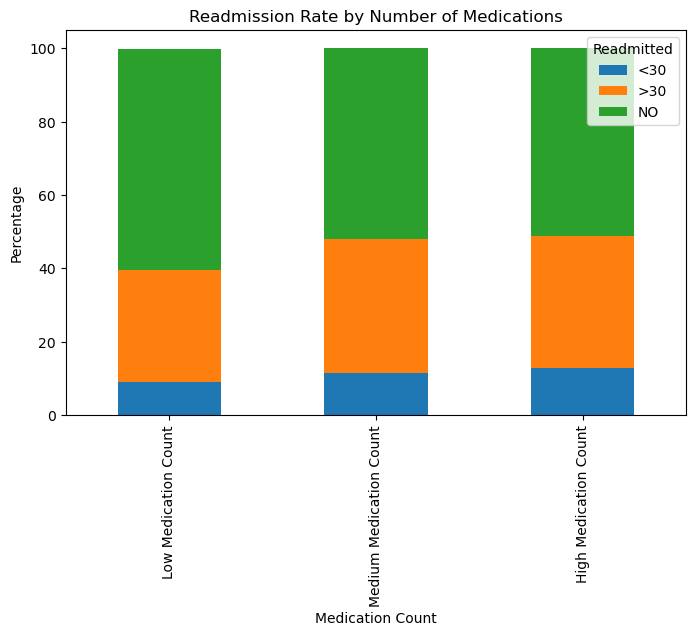

In [87]:
medication_count_readmission.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Readmission Rate by Number of Medications')
plt.xlabel('Medication Count')
plt.ylabel('Percentage')
plt.legend(title='Readmitted')
plt.show()

Key Findings
Patients with a High Medication Count have the highest 30-day readmission rate (12.78%), compared to 11.46% for Medium and 9.06% for Low Medication Count.
Patients in the Medium Medication Count group show the highest readmission after 30 days (36.66%), closely followed by the High Medication Count group at 35.97%.
The percentage of patients with no readmission decreases as medication count increases:
Low Medication Count: 60.45%
Medium Medication Count: 51.88%
High Medication Count: 51.26%
Overall, patients prescribed more medications are less likely to avoid readmission, indicating that medication burden is associated with increased readmission risk.

Business Insight

A higher medication count often reflects greater disease severity and more complex treatment plans. Patients managing multiple medications may face challenges such as medication interactions, adherence issues, or treatment complexity, all of which can contribute to a higher likelihood of hospital readmission.

Recommendation

Hospitals should implement enhanced medication management for patients prescribed multiple medications. This includes medication reconciliation before discharge, pharmacist-led counseling, simplified medication schedules where possible, and early follow-up to improve adherence and reduce preventable readmissions.

Business Impact

Strengthening medication management for high-risk patients can improve treatment adherence, reduce medication-related complications, lower hospital readmission rates, optimize healthcare resources, and improve overall quality of patient care

## Business Question 11: Does the Number of Lab Procedures Influence Hospital Readmission?

### Objective
Analyze whether patients who undergo a higher number of laboratory procedures are more likely to be readmitted within 30 days, after 30 days, or not readmitted.

### Why This Matters
A higher number of laboratory procedures may indicate more severe or complex medical conditions. Identifying this relationship helps hospitals recognize high-risk patients and improve discharge planning and post-hospital care.

In [88]:
df['lab_procedure_load'] = pd.cut(
    df['num_lab_procedures'],
    bins=[0, 40, 60, 132],
    labels=['Low Lab Procedures', 'Medium Lab Procedures', 'High Lab Procedures'],
    include_lowest=True
)

In [89]:
lab_readmission = (
    pd.crosstab(
        df['lab_procedure_load'],
        df['readmitted'],
        normalize='index'
    ) * 100
).round(2)

lab_readmission

readmitted,<30,>30,NO
lab_procedure_load,,,
Low Lab Procedures,10.39,33.52,56.09
Medium Lab Procedures,11.61,35.34,53.06
High Lab Procedures,11.92,37.15,50.93


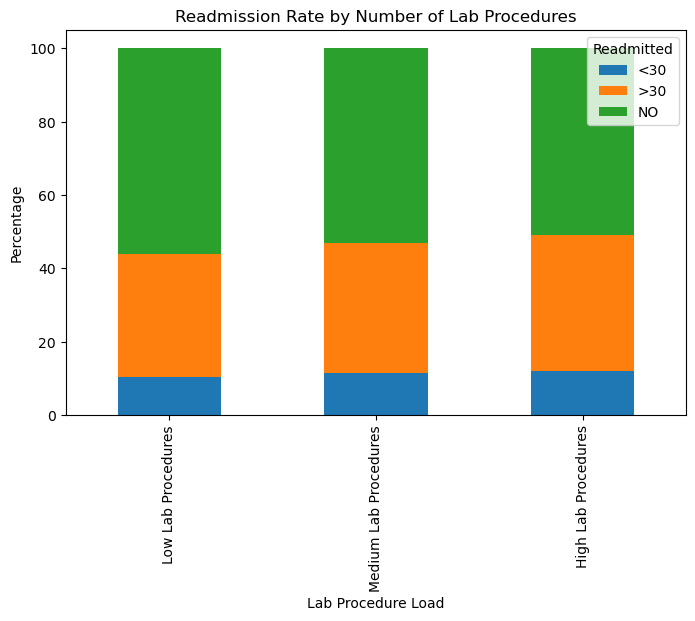

In [90]:
lab_readmission.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Readmission Rate by Number of Lab Procedures')
plt.xlabel('Lab Procedure Load')
plt.ylabel('Percentage')
plt.legend(title='Readmitted')
plt.show()

 Key Findings
Patients with a High Lab Procedure Load have the highest readmission rates, with 11.92% readmitted within 30 days and 37.15% after 30 days.
Patients with a Low Lab Procedure Load show the lowest readmission rates, with 10.39% readmitted within 30 days and 33.52% after 30 days.
The percentage of patients with no readmission declines as the number of lab procedures increases:
Low Lab Procedures: 56.09%
Medium Lab Procedures: 53.06%
High Lab Procedures: 50.93%
Overall, there is a gradual increase in readmission rates as the number of laboratory procedures rises, suggesting an association between clinical complexity and hospital readmission.

Business Insight

Patients undergoing a larger number of laboratory procedures are likely receiving more extensive diagnostic evaluations due to complex or severe medical conditions. This increased clinical complexity is associated with a higher probability of hospital readmission, making lab procedure volume a useful indicator for identifying high-risk patients.

Recommendation

Hospitals should use the number of laboratory procedures as one of the indicators in their readmission risk assessment models. Patients with a high lab procedure load should receive enhanced discharge planning, closer clinical monitoring, and timely follow-up care to reduce the likelihood of avoidable readmissions.

Business Impact

Incorporating laboratory procedure volume into patient risk stratification can help hospitals identify vulnerable patients earlier, allocate care management resources more effectively, improve patient outcomes, and reduce costs associated with preventable readmissions.

## Business Question 12: Does A1C Test Result Influence Hospital Readmission?

### Objective
Analyze whether patients with different A1C test results have different hospital readmission rates.

### Why This Matters
The A1C test measures a patient's average blood glucose level over the past 2–3 months. Poor glycemic control is associated with diabetes-related complications and may increase the likelihood of hospital readmission. Understanding this relationship can help hospitals identify patients who require additional diabetes management and follow-up care.

In [91]:
df['A1C_Result_Group'] = df['A1Cresult'].replace({
    '>7': 'Abnormal',
    '>8': 'Abnormal',
    'Norm': 'Normal',
    'None': 'Not Tested'
})

In [92]:
a1c_readmission = (
    pd.crosstab(
        df['A1C_Result_Group'],
        df['readmitted'],
        normalize='index'
    ) * 100
).round(2)

a1c_readmission

readmitted,<30,>30,NO
A1C_Result_Group,,,
Abnormal,9.93,34.93,55.15
Normal,9.66,32.04,58.30


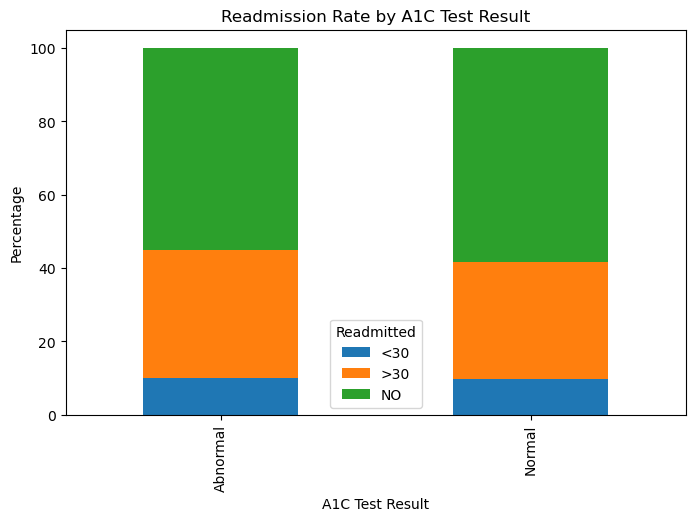

In [93]:
a1c_readmission.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Readmission Rate by A1C Test Result')
plt.xlabel('A1C Test Result')
plt.ylabel('Percentage')
plt.legend(title='Readmitted')
plt.show()

In [94]:

df['A1Cresult'].value_counts()

A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

 Key Findings
Patients with Abnormal A1C results have the highest readmission rates, with 9.93% readmitted within 30 days and 34.93% after 30 days.
Patients with Normal A1C results show slightly lower readmission rates, with 9.66% readmitted within 30 days and 32.04% after 30 days.
The percentage of patients with no readmission is higher among those with Normal A1C results (58.30%) compared to patients with Abnormal A1C results (55.15%).
Overall, patients with poor blood glucose control (Abnormal A1C) exhibit a slightly greater likelihood of hospital readmission than those with normal A1C levels.

 Business Insight

A1C reflects long-term blood glucose control in diabetic patients. The higher readmission rates observed among patients with abnormal A1C values suggest that poor glycemic control may contribute to complications requiring additional hospital care. Although the difference is modest, A1C remains an important clinical indicator for identifying patients who may benefit from closer monitoring after discharge.

 Recommendation

Hospitals should prioritize diabetes management for patients with abnormal A1C results by providing personalized discharge counseling, medication optimization, blood glucose monitoring plans, and timely follow-up appointments. Strengthening diabetes education may help reduce preventable readmissions.

 Business Impact

Using A1C results as part of the hospital's readmission risk assessment can support early intervention for diabetic patients. Improved glycemic management can enhance patient outcomes, reduce repeat hospitalizations, and optimize healthcare resource utilization.

## Business Question 13: Does Insulin Treatment Influence Hospital Readmission?

### Objective
Analyze whether different insulin treatment statuses are associated with hospital readmission rates.

### Why This Matters
Insulin therapy is a key component of diabetes management. Changes in insulin treatment may reflect disease severity or treatment adjustments. Understanding its relationship with readmission can help healthcare providers identify patients who require closer monitoring after discharge.

In [95]:
df['Insulin_Status'] = df['insulin'].replace({
    'No': 'No Insulin',
    'Steady': 'Steady',
    'Up': 'Dose Changed',
    'Down': 'Dose Changed'
})

In [96]:
insulin_readmission = (
    pd.crosstab(
        df['Insulin_Status'],
        df['readmitted'],
        normalize='index'
    ) * 100
).round(2)

insulin_readmission

readmitted,<30,>30,NO
Insulin_Status,,,
Dose Changed,13.46,38.73,47.81
No Insulin,10.04,33.66,56.30
Steady,11.13,33.98,54.89


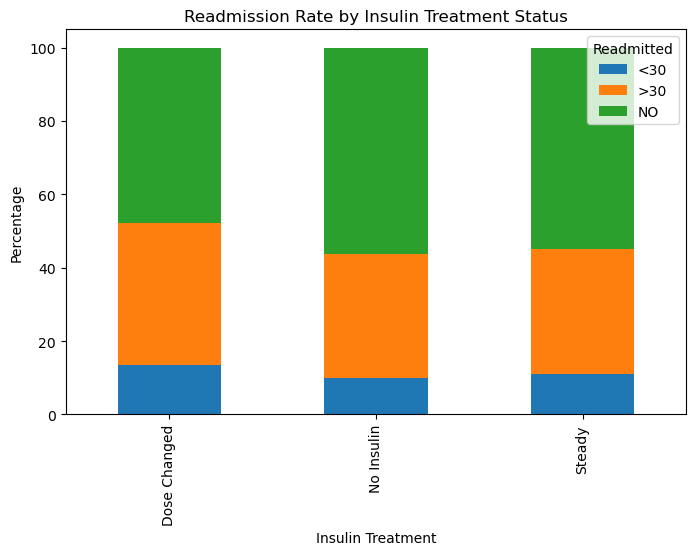

In [97]:
insulin_readmission.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Readmission Rate by Insulin Treatment Status')
plt.xlabel('Insulin Treatment')
plt.ylabel('Percentage')
plt.legend(title='Readmitted')
plt.show()

 Key Findings
Patients with Dose Changed insulin therapy have the highest readmission rates, with 13.46% readmitted within 30 days and 38.73% after 30 days.
Patients receiving No Insulin have the lowest readmission rates, with 10.04% readmitted within 30 days and 33.66% after 30 days.
Patients with Steady insulin treatment show intermediate readmission rates, with 11.13% readmitted within 30 days and 33.98% after 30 days.
The percentage of patients with no readmission is lowest among the Dose Changed group (47.81%), compared to 54.89% for the Steady group and 56.30% for the No Insulin group.

 Business Insight

Patients whose insulin dosage is adjusted during hospitalization appear to have the highest risk of readmission. A change in insulin dosage may indicate unstable blood glucose levels, disease progression, or the need for treatment modification. These patients are likely to require closer monitoring after discharge.

 Recommendation

Hospitals should classify patients with insulin dose changes as a high-risk group for readmission. These patients should receive comprehensive diabetes education, medication counseling, individualized discharge plans, and early follow-up appointments to ensure effective blood glucose management after leaving the hospital.

Business Impact

Using insulin treatment status as part of the readmission risk assessment can help healthcare providers identify vulnerable diabetic patients earlier. Targeted interventions for patients with insulin dose changes can improve treatment adherence, reduce avoidable readmissions, enhance patient outcomes, and lower healthcare costs.

## Business Question 14: Does Diabetes Medication Usage Affect Hospital Readmission?

### Objective
Analyze whether patients taking diabetes medication have different hospital readmission rates compared to those who are not receiving diabetes medication.

### Why This Matters
Diabetes medication plays a crucial role in controlling blood glucose levels. Understanding whether medication usage is associated with hospital readmission can help healthcare providers evaluate treatment effectiveness and identify patients who may require additional follow-up care.

In [98]:
diabetes_med_readmission = (
    pd.crosstab(
        df['diabetesMed'],
        df['readmitted'],
        normalize='index'
    ) * 100
).round(2)

diabetes_med_readmission

readmitted,<30,>30,NO
diabetesMed,,,
No,9.60,30.88,59.52
Yes,11.63,36.14,52.24


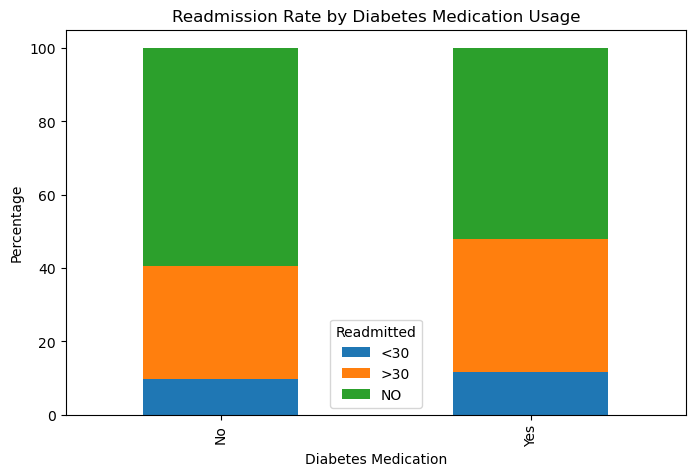

In [99]:
diabetes_med_readmission.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Readmission Rate by Diabetes Medication Usage')
plt.xlabel('Diabetes Medication')
plt.ylabel('Percentage')
plt.legend(title='Readmitted')
plt.show()

 Key Findings
Patients receiving diabetes medication have a higher 30-day readmission rate (11.63%) compared to patients not receiving diabetes medication (9.60%).
The readmission after 30 days is also higher among patients taking diabetes medication (36.14%) than those not taking medication (30.88%).
Patients not receiving diabetes medication have the highest percentage of no readmission (59.52%), while patients on diabetes medication have a lower no-readmission rate (52.24%).
Overall, patients taking diabetes medication experience higher readmission rates than those who are not.

Business Insight

Patients prescribed diabetes medication often have more advanced or actively managed diabetes, which may indicate greater disease severity. Therefore, the higher readmission rates observed in this group are likely associated with underlying clinical complexity rather than the medication itself. This highlights the importance of providing additional support to patients with ongoing diabetes treatment

Recommendation

Hospitals should strengthen discharge planning for patients receiving diabetes medication by providing medication counseling, self-management education, blood glucose monitoring guidance, and timely follow-up appointments. These interventions can improve treatment adherence and help reduce preventable readmissions.

Business Impact

Identifying patients on diabetes medication as a higher-risk population enables hospitals to prioritize post-discharge care, improve chronic disease management, reduce avoidable readmissions, and optimize healthcare resource utilization.

In [100]:
df_clean.shape

(100241, 52)

In [101]:
df_clean.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_visits,visit_category,stay_category,medication_load,diagnosis_complexity,age_midpoint,readmission_binary,admission_type
0,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0,No Previous Visits,Short Stay,Medium Medication,High Complexity,15,1,Emergency
1,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,3,Moderate Utilization,Short Stay,Medium Medication,Medium Complexity,25,0,Emergency
2,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,No Previous Visits,Short Stay,Medium Medication,Medium Complexity,35,0,Emergency
3,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0,No Previous Visits,Short Stay,Low Medication,Low Complexity,45,0,Emergency
4,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,Unknown,31,6,16,0,0,0,414,411,250,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,0,No Previous Visits,Short Stay,Medium Medication,High Complexity,55,1,Urgent


# Final EDA Summary

## Overall Findings

- Elderly diabetic patients (60–80 years) represented the largest patient population.
- Nearly half of all patients experienced at least one hospital readmission.
- Longer hospital stays were associated with higher readmission rates.
- Higher medication burden was associated with increased readmission.
- Emergency admissions showed higher readmission than elective admissions.
- Gender showed minimal differences in readmission patterns.
- Older age groups demonstrated higher readmission risk.
- Patients with complex clinical profiles required greater follow-up care.

---

## Top Business Recommendations

1. Strengthen discharge planning for high-risk patients.
2. Enhance medication counseling before discharge.
3. Implement age-focused chronic disease management.
4. Prioritize emergency admissions for follow-up.
5. Monitor patients with longer hospital stays.
6. Improve medication adherence programs.
7. Schedule early post-discharge follow-ups.
8. Use risk-based patient stratification.

In [102]:
df_clean.to_csv(
    "healthcare_feature_engineered_final.csv",
    index=False
)